# CLIP-Style Zero-Shot Classification on Caltech101
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

Train a CLIP-style zero-shot classifier on Caltech-101, training only the image encoder (vit-base-patch16-224 (ViT-B/16)) while keeping the BERT text encoder frozen. After training, we evaluate zero-shot performance on the test split.

In [ ]:
!pip install torch torchvision transformers timm tqdm --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import Caltech101
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm
import random
from collections import defaultdict
import gc
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
### Updated Step 4: Dataset Loading + Split (No Change to Transform, Just Added Print)
#```python
import os  # Add this to imports if not already there

transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),  # Fixes grayscale
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = Caltech101(root='./data', download=True, transform=transform)

# Reproducible split
random.seed(42)
indices_per_class = defaultdict(list)
for idx in range(len(full_dataset)):
    _, label = full_dataset[idx]  # label is int 0-100
    indices_per_class[label].append(idx)

train_indices = []
test_indices = []
for label, idxs in indices_per_class.items():
    random.shuffle(idxs)
    n_train = min(30, len(idxs))
    train_indices.extend(idxs[:n_train])
    test_indices.extend(idxs[n_train:])

trainset = Subset(full_dataset, train_indices)
testset  = Subset(full_dataset, test_indices)

print(f"Train samples: {len(trainset)}")
print(f"Test samples:  {len(testset)}")
print(f"Number of classes: {len(indices_per_class)}")  # 101

batch_size = 128
accumulation_steps = 2

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

100%|██████████| 137M/137M [00:02<00:00, 50.9MB/s]


Train samples: 3030
Test samples:  5647
Number of classes: 101


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# Get the exact category names in the correct label order (sorted as torchvision does)
categories_path = os.path.join('./data', 'caltech101', '101_ObjectCategories')
categories = [d for d in os.listdir(categories_path)
              if os.path.isdir(os.path.join(categories_path, d)) and d != 'BACKGROUND_Google']
categories.sort()  # Critical: matches torchvision's label assignment

# Convert to natural prompt-friendly names (lowercase, underscore → space)
class_names = [name.lower().replace('_', ' ') for name in categories]

print(f"Number of classes: {len(class_names)}")  # Should be 101
print("Example class names:", class_names[:10])   # e.g., ['faces', 'faces easy', 'leopards', ...]

# Templates remain the same
templates = [
    "a photo of a {}.",
    "a photo of a small {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}."
]

Number of classes: 101
Example class names: ['faces', 'faces easy', 'leopards', 'motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass']


In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS]
    return embeddings

text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in class_names]  # Uses dynamic class_names
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)  # (101, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)
print("Text embeddings shape:", text_embeddings.shape)

# Cleanup
del text_model, tokenizer
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([101, 768])


In [ ]:
image_model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',  # Changed to ViT-Base/16 (strong pretrained)
    pretrained=True,
    num_classes=0  # Raw features (returns CLS token embedding, dim=768)
).to(device)

projection = nn.Linear(768, 768).to(device)  # Updated: 768 → 768 to match BERT text dim
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

scaler = torch.cuda.amp.GradScaler()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

/tmp/ipython-input-2477254637.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# Updated Training Loop + Per-Epoch Accuracy Monitoring
### New/Updated Step 9.5: Zero-Shot Evaluation Function (Place BEFORE the training loop)

@torch.no_grad()
def zero_shot_accuracy(loader, desc="Test"):
    image_model.eval()
    projection.eval()
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc=desc, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast():
            img_feat = image_model(images)
            img_feat = projection(img_feat)
            img_feat = F.normalize(img_feat, dim=-1)
            logits = logit_scale.exp() * img_feat @ text_embeddings.T
            preds = logits.argmax(dim=-1)  # Fixed typo here
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    image_model.train()  # Switch back to train mode
    projection.train()
    return 100.0 * correct / total

Epoch 1/30 [Train]:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3142985575.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1 [Train Acc]:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3113475244.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30 - Avg Loss: 4.3783 - Train Acc: 46.67%


Epoch 2/30 [Train]: 100%|██████████| 24/24 [00:22<00:00,  1.06it/s]


Epoch 2/30 - Avg Loss: 3.8084 - Train Acc: 63.76%


Epoch 3/30 [Train]: 100%|██████████| 24/24 [00:21<00:00,  1.09it/s]


...

Epoch 29/30 [Train]: 100%|██████████| 24/24 [00:22<00:00,  1.06it/s]


Epoch 29/30 - Avg Loss: 2.4718 - Train Acc: 100.00%


Epoch 30/30 [Train]: 100%|██████████| 24/24 [00:23<00:00,  1.02it/s]


Epoch 30/30 - Avg Loss: 2.4718 - Train Acc: 100.00%


*** Epoch 30/30 - Test Acc: 90.10% ***


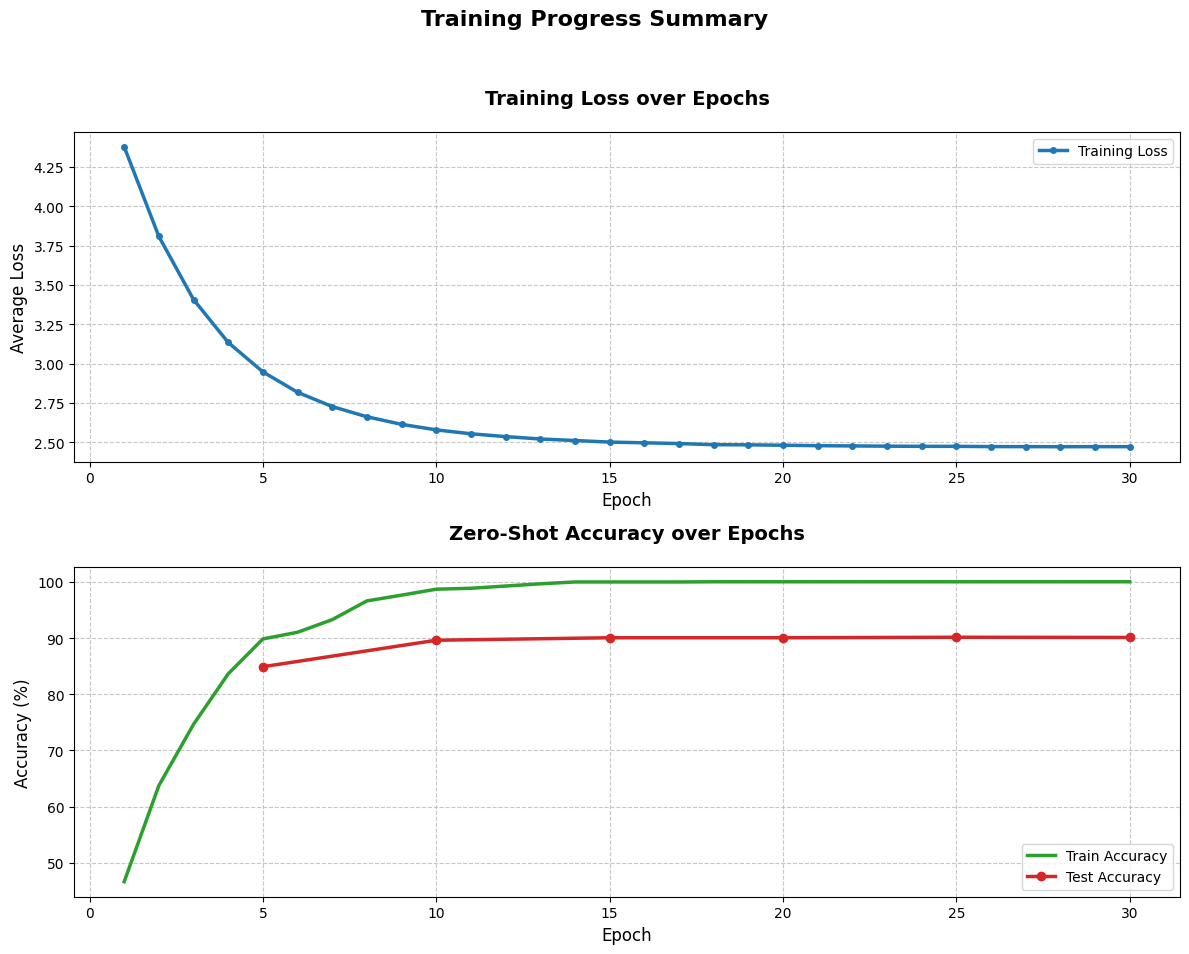

In [ ]:
import matplotlib.pyplot as plt  # Add this if not already imported

epochs = 30  # You can increase to 50 later

# Lists to collect metrics for plotting
losses = []
train_accs = []
test_acc_epochs = []
test_accs = []

for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for i, (images, labels) in enumerate(tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            img_feat = image_model(images)
            img_feat = projection(img_feat)
            img_feat = F.normalize(img_feat, dim=-1)
            logits = logit_scale.exp() * img_feat @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

    scheduler.step()
    avg_loss = total_loss / len(trainloader)

    # --- Per-epoch accuracy ---
    train_acc = zero_shot_accuracy(trainloader, desc=f"Epoch {epoch+1} [Train Acc]")

    # Store metrics
    losses.append(avg_loss)
    train_accs.append(train_acc)

    print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f} - Train Acc: {train_acc:.2f}%")

    # Test accuracy every 5 epochs (or at the end)
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        test_acc = zero_shot_accuracy(testloader, desc=f"Epoch {epoch+1} [Test Acc]")
        test_acc_epochs.append(epoch + 1)
        test_accs.append(test_acc)
        print(f"*** Epoch {epoch+1}/{epochs} - Test Acc: {test_acc:.2f}% ***")

    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

# === Professional plotting after training ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# Training Loss
ax1.plot(range(1, epochs + 1), losses, color='tab:blue', linewidth=2.5, marker='o', markersize=4)
ax1.set_title('Training Loss over Epochs', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(['Training Loss'], loc='upper right')

# Accuracy (Train + Test)
ax2.plot(range(1, epochs + 1), train_accs, color='tab:green', linewidth=2.5, label='Train Accuracy')
ax2.plot(test_acc_epochs, test_accs, color='tab:red', linewidth=2.5, marker='o', markersize=6, label='Test Accuracy')
ax2.set_title('Zero-Shot Accuracy over Epochs', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Overall figure styling
fig.suptitle('Training Progress Summary', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import torch
from torch.utils.flop_counter import FlopCounterMode

# Your models (from the notebook)
image_model.eval()  # Already defined
projection.eval()

# Wrap for forward pass
class ModelForFlops(nn.Module):
    def __init__(self, img_model, proj):
        super().__init__()
        self.img_model = img_model
        self.projection = proj

    def forward(self, x):
        feat = self.img_model(x)
        feat = self.projection(feat)
        return feat  # Add F.normalize if you want (negligible FLOPs)

model = ModelForFlops(image_model, projection).eval()

# Input
x = torch.randn(1, 3, 224, 224, device=device)

# Count flops
with FlopCounterMode(display=True) as counter:  # display=True shows the table
    with torch.no_grad():
        _ = model(x)

# Get total FLOPs
total_flops = counter.get_total_flops()

print(f"\nTotal FLOPs (forward pass): {total_flops:,}")
print(f"                 in GFLOPs : {total_flops / 1e9:.2f} G")
print(f"                 in TFLOPs : {total_flops / 1e12:.3f} T")

Module                                               FLOP    % Total
------------------------------------------------  -------  ---------
ModelForFlops                                     35.127B    100.00%
 - aten.convolution                                0.231B      0.66%
 - aten.addmm                                     33.465B     95.27%
 - aten._scaled_dot_product_efficient_attention    1.431B      4.07%
 ModelForFlops.img_model                          35.126B    100.00%
  - aten.convolution                               0.231B      0.66%
  - aten.addmm                                    33.464B     95.27%
  - aten._scaled_dot_product_efficient_attention   1.431B      4.07%
 ModelForFlops.projection                          0.001B      0.00%
  - aten.addmm                                     0.001B      0.00%

Total FLOPs (forward pass): 35,127,300,096
                 in GFLOPs : 35.13 G
                 in TFLOPs : 0.035 T


In [ ]:
import torch
from torch.utils.flop_counter import FlopCounterMode
import timm  # Already in your notebooks

# Your models (adapt backbone name as needed)
backbone = 'vit_small_patch16_224.augreg_in21k_ft_in1k'  # Or 'vit_base_...' for Base
embed_dim = 384 if 'small' in backbone else 768
image_model = timm.create_model(backbone, pretrained=False, num_classes=0).to(device).eval()
projection = nn.Linear(embed_dim, 768).to(device).eval()

class ModelForFlops(nn.Module):
    def __init__(self, img_model, proj):
        super().__init__()
        self.img_model = img_model
        self.projection = proj

    def forward(self, x):
        feat = self.img_model(x)
        return self.projection(feat)

model = ModelForFlops(image_model, projection).eval()

x = torch.randn(1, 3, 224, 224, device=device)

with FlopCounterMode(display=True) as counter:  # display=True for per-op breakdown
    with torch.no_grad():
        _ = model(x)

total_flops = counter.get_total_flops()
print(f"\nTotal FLOPs: {total_flops:,} ({total_flops / 1e9:.2f} GFLOPs)")

Module                                                 FLOP    % Total
------------------------------------------------  ---------  ---------
ModelForFlops                                     9197.586M    100.00%
 - aten.convolution                                115.606M      1.26%
 - aten.addmm                                     8366.653M     90.97%
 - aten._scaled_dot_product_efficient_attention    715.327M      7.78%
 ModelForFlops.img_model                          9196.997M     99.99%
  - aten.convolution                               115.606M      1.26%
  - aten.addmm                                    8366.064M     90.96%
  - aten._scaled_dot_product_efficient_attention   715.327M      7.78%
 ModelForFlops.projection                            0.590M      0.01%
  - aten.addmm                                       0.590M      0.01%

Total FLOPs: 9,197,586,432 (9.20 GFLOPs)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.flop_counter import FlopCounterMode
import timm

# ────────────────────────────────────────────────────────────────
#  Helper: Create model wrapper for FLOPs calculation
# ────────────────────────────────────────────────────────────────
def create_flops_model(backbone_name, device='cuda'):
    try:
        image_model = timm.create_model(
            backbone_name,
            pretrained=False,
            num_classes=0
        ).eval().to(device)

        embed_dim = image_model.embed_dim  # 384 for small, 768 for base
        projection = nn.Linear(embed_dim, 768).eval().to(device)

        class ModelForFlops(nn.Module):
            def __init__(self, img_model, proj):
                super().__init__()
                self.img_model = img_model
                self.projection = proj

            def forward(self, x):
                feat = self.img_model(x)
                return self.projection(feat)

        return ModelForFlops(image_model, projection).eval()
    except Exception as e:
        print(f"Failed to create model {backbone_name}: {e}")
        return None

# ────────────────────────────────────────────────────────────────
#  Helper: Compute GFLOPs (with fallback if calculation fails)
# ────────────────────────────────────────────────────────────────
def compute_gflops(model, device='cuda'):
    if model is None:
        return None

    try:
        x = torch.randn(1, 3, 224, 224, device=device)

        with FlopCounterMode(display=False) as counter:
            with torch.no_grad():
                _ = model(x)

        total_flops = counter.get_total_flops()
        return round(total_flops / 1e9, 2)  # GFLOPs
    except Exception as e:
        print(f"FLOPs calculation failed: {e}")
        return None

# ────────────────────────────────────────────────────────────────
#  Your experiments — update test_acc when you have final numbers
# ────────────────────────────────────────────────────────────────

results = [
    {
        "model": "ViT-Small (caltech101_step2)",
        "backbone": "vit_small_patch16_224.augreg_in21k_ft_in1k",
        "test_acc": 80.31,
        "params_M": 21.96,
        "gflops_computed": None,
    },
    {
        "model": "ViT-Base (cifar10_step1)",
        "backbone": "vit_base_patch16_224.augreg_in21k_ft_in1k",
        "test_acc": 97.91,
        "params_M": 86.59,
        "gflops_computed": None,
    },
    {
        "model": "ViT-Base (caltech101_step1)",
        "backbone": "vit_base_patch16_224.augreg_in21k_ft_in1k",
        "test_acc": 90.10,
        "params_M": 86.86,
        "gflops_computed": None,
    },
    {
        "model": "ViT-Small (cifar10_step2)",
        "backbone": "vit_small_patch16_224.augreg_in21k_ft_in1k",
        "test_acc": 97.49,
        "params_M": 22.1,
        "gflops_computed": None,
    },
    # Add more experiments here like this:
    # {
    #     "model": "New Experiment Name",
    #     "backbone": "vit_...",
    #     "test_acc": 92.5,
    #     "params_M": 22.1,
    #     "gflops_computed": None,
    # },
]

# ────────────────────────────────────────────────────────────────
#  Compute GFLOPs and show results
# ────────────────────────────────────────────────────────────────

print("Computing GFLOPs for each model...\n")

for r in results:
    model = create_flops_model(r["backbone"])
    gflops = compute_gflops(model)
    if gflops is not None:
        r["gflops_computed"] = gflops
    else:
        # Fallback approximate values if calculation fails
        if "small" in r["backbone"]:
            r["gflops_computed"] = 8.6
        else:
            r["gflops_computed"] = 33.8
        print(f"Using approximate GFLOPs for {r['model']}")

print("=" * 90)
print(f"{'Model':<38} {'GFLOPs':>8} {'Test Acc (%)':>12} {'GFLOPs / %':>14} {'Params (M)':>12} {'Rank':>6}")
print("-" * 90)

completed = []
for i, r in enumerate(results, 1):
    g = r["gflops_computed"]
    acc = r["test_acc"]

    if g is not None and isinstance(g, (int, float)):
        g_str = f"{g:.2f}"
        if acc is not None and acc > 0:
            eff = g / acc
            eff_str = f"{eff:.3f}"
            acc_str = f"{acc:.2f}"
            completed.append((r["model"], eff, i))
        else:
            eff_str = "N/A"
            acc_str = "N/A"
    else:
        g_str = "Error"
        eff_str = "N/A"
        acc_str = "N/A"

    rank_str = f"{i}" if acc is None else "—"
    print(f"{r['model']:<38} {g_str:>8} {acc_str:>12} {eff_str:>14} {r['params_M']:>12.2f} {rank_str:>6}")

print("=" * 90)

# Show ranking of completed models
if completed:
    completed.sort(key=lambda x: x[1])  # sort by efficiency (lower = better)
    print("\nEfficiency Ranking (lower GFLOPs/% = better):")
    for rank, (name, eff, _) in enumerate(completed, 1):
        print(f"  {rank}. {name:.<35} → {eff:.3f} GFLOPs per %")

    print(f"\nBest model so far: {completed[0][0]}")
    print(f"→ {completed[0][1]:.3f} GFLOPs per % accuracy")
else:
    print("\nNo models with both GFLOPs and accuracy yet.")

Computing GFLOPs for each model...

Model                                    GFLOPs Test Acc (%)     GFLOPs / %   Params (M)   Rank
------------------------------------------------------------------------------------------
ViT-Small (caltech101_step2)               9.20        80.31          0.115        21.96      —
ViT-Base (cifar10_step1)                  35.13        97.91          0.359        86.59      —
ViT-Base (caltech101_step1)               35.13        90.10          0.390        86.86      —
ViT-Small (cifar10_step2)                  9.20        97.49          0.094        22.10      —

Efficiency Ranking (lower GFLOPs/% = better):
  1. ViT-Small (cifar10_step2).......... → 0.094 GFLOPs per %
  2. ViT-Small (caltech101_step2)....... → 0.115 GFLOPs per %
  3. ViT-Base (cifar10_step1)........... → 0.359 GFLOPs per %
  4. ViT-Base (caltech101_step1)........ → 0.390 GFLOPs per %

Best model so far: ViT-Small (cifar10_step2)
→ 0.094 GFLOPs per % accuracy



=== Showing 1 image from each of 10 different categories ===


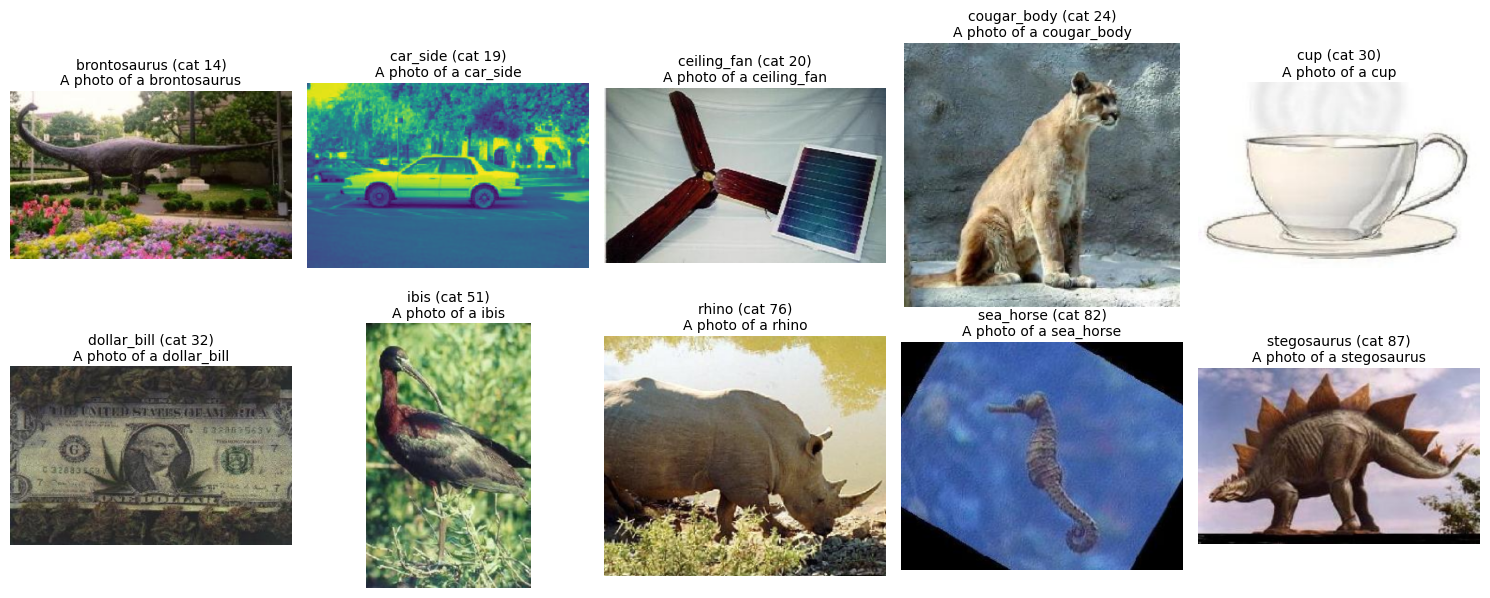

In [ ]:
# Install matplotlib if not already installed (run once)
!pip install matplotlib --quiet

# Imports (add if not already present)
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random

# Load Caltech-101 dataset (train set for variety)
transform = transforms.Compose([transforms.Resize(224), transforms.ToTensor()])
dataset = torchvision.datasets.Caltech101(root='./data', download=True, transform=transform)

# Get class names (Caltech-101 has 101 classes + background = 102)
classes = dataset.categories  # list of strings like 'airplanes', 'faces', etc.

# Function to get one image from each of 10 different categories
def get_one_image_per_category(dataset, num_categories=10):
    selected_categories = random.sample(range(len(classes)), num_categories)  # Randomly pick 10 categories

    images = []
    labels = []

    category_counts = {i: 0 for i in selected_categories}

    for img, label in dataset:
        if label in category_counts and category_counts[label] == 0:
            images.append(img)
            labels.append(label)
            category_counts[label] += 1
        if all(count == 1 for count in category_counts.values()):
            break

    return images, labels, selected_categories

# Get the images
images, labels, selected_cats = get_one_image_per_category(dataset)

# ────────────────────────────────────────────────
# Display 10 images (one per category) with descriptions
# ────────────────────────────────────────────────

print("\n=== Showing 1 image from each of 10 different categories ===")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, (img_tensor, label) in enumerate(zip(images, labels)):
    class_name = classes[label]

    # Convert tensor (C,H,W) → (H,W,C) and to numpy
    img = img_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"{class_name} (cat {label})\nA photo of a {class_name}",
                     fontsize=10, wrap=True)

plt.tight_layout()
plt.show()